# Motion models and Kalman filter

In [2]:
# Imports
import numpy as np
from ex4_utils import kalman_step
import math
import matplotlib.pyplot as plt
import sympy as sp
from sympy.interactive.printing import init_printing
init_printing(use_unicode=False, wrap_line=False)

## Deriving the matrices

### Random walk

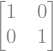

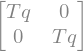

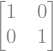

In [3]:
# NOTE: state is [x,y]
# Here we only use the random component
T_RW, q_RW = sp.symbols('T, q')
F_RW = sp.Matrix([[0,0],[0,0]])
Fi_RW = sp.exp(F_RW*T_RW)
display(Fi_RW)
L_RW = sp.Matrix([
    [1, 0],
    [0, 1]
])
Q_RW = sp.integrate((Fi_RW * L_RW) * q_RW * (Fi_RW  * L_RW).T, (T_RW, 0, T_RW) )
display(Q_RW)
H_RW = sp.Matrix([[1,0], [0,1]])
display(H_RW)

### Nearly constant velocity

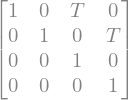

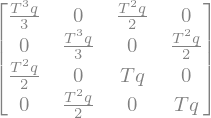

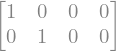

In [4]:
# NOTE: state is [x,y, x_vel, y_vel]
T_NCV, q_NCV = sp.symbols('T, q')
F_NCV = sp.Matrix([[0,0, 1,0],[0,0,0,1], [0,0,0,0], [0,0,0,0]])
Fi_NCV = sp.exp(F_NCV * T_NCV)
display(Fi_NCV)
L_NCV = sp.Matrix([
    [0, 0],
    [0, 0],
    [1, 0],
    [0, 1]
])
# The covariance matrix
Q_NCV = sp.integrate((Fi_NCV * L_NCV) * q_NCV * (Fi_NCV  * L_NCV).T, (T_NCV, 0, T_NCV) )
display(Q_NCV)
H_NCV = sp.Matrix([[1,0,0,0], [0,1,0,0]])
display(H_NCV)

### Nearly constant acceleration

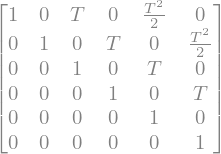

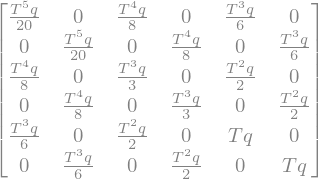

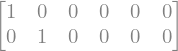

In [5]:
# NOTE: state is [x,y, x_vel, y_vel, x_acc, y_acc]
T_NCA,q_NCA= sp.symbols('T, q')
F_NCA = sp.Matrix([[0,0, 1,0,0,0],[0,0,0,1,0,0], [0,0,0,0,1,0], [0,0,0,0,0,1], [0,0,0,0,0,0], [0,0,0,0,0,0]])
Fi_NCA = sp.exp(F_NCA * T_NCA)
display(Fi_NCA)
L_NCA = sp.Matrix([
    [0, 0],
    [0, 0],
    [0, 0],
    [0, 0],    
    [1, 0],
    [0, 1]
])
Q_NCA = sp.integrate((Fi_NCA * L_NCA) * q_NCA * (Fi_NCA  * L_NCA).T, (T_NCA, 0, T_NCA))
display(Q_NCA)
H_NCA = sp.Matrix([[1,0,0,0,0,0], [0,1,0,0,0,0]])
display(H_NCA)


## Artificial tests

In [6]:
# Artificial tests
N = 40
v = np.linspace(5 * math.pi, 0, N)
x = np.cos(v) * v
y = np.sin(v) * v


def test_kalman(x,y, A, C, Q_i, R_i):
    sx = np.zeros((x.size,1), dtype=np.float32).flatten()
    sy = np.zeros((y.size, 1), dtype=np.float32).flatten()

    sx[0] = x[0]
    sy[0] = y[0]

    state = np.zeros((A.shape[0]), dtype=np.float32).flatten()
    state[0] = x[0]
    covariance = np.eye(A.shape[0],  dtype=np.float32)

    for j in range(1, x.size):
        state, covariance, _ , _ = kalman_step(A, C, Q_i, R_i, 
                                               np.reshape(np.array([x[j], y[j]]),(-1,1))
                                               ,np.reshape(state, (-1,1)), covariance)
        sx[j] = state[0]
        sy[j] = state[1]

    return sx,sy


C:\Users\marko\AppData\Local\Temp\ipykernel_8416\914359342.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sx[j] = state[0]
C:\Users\marko\AppData\Local\Temp\ipykernel_8416\914359342.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sy[j] = state[1]


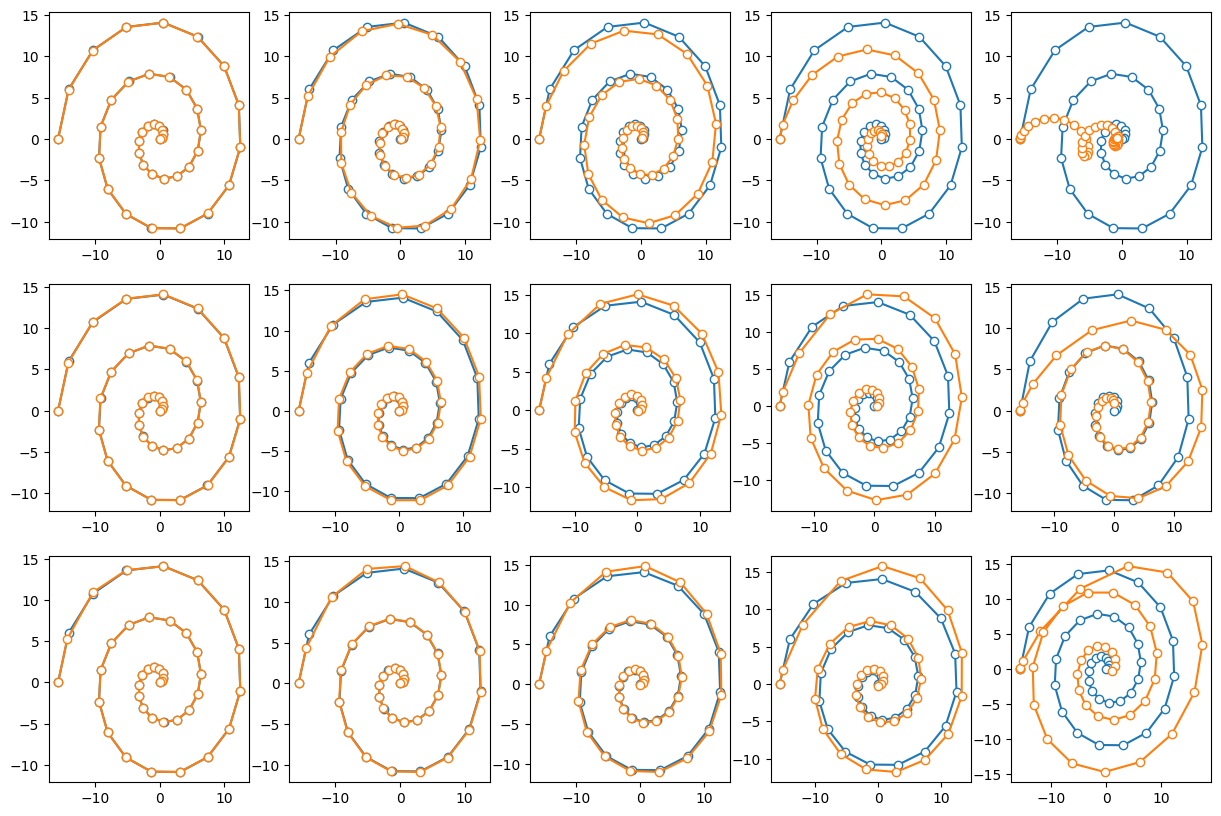

In [ ]:
# Subplot with different params
T = 1
fig, ax = plt.subplots(3, 5, figsize=(15,10)) 
for i,( q, r) in enumerate(zip([100,5,1,1,1], [1,1,1,5,100])):
    # RANDOM WALK
    Fi_RW_np = Fi_RW.evalf(subs={T_RW:T, q_RW:q})
    Fi_RW_np = np.array(Fi_RW_np.tolist(), dtype=float)

    Q_RW_np = Q_RW.evalf(subs={T_RW:T, q_RW: q})
    Q_RW_np = np.array(Q_RW_np.tolist(), dtype=float)

    H_np = np.array(H_RW.tolist(), dtype=float) 

    R = r * np.array([[1,0], [0,1]])  
    sx,sy = test_kalman(x,y,Fi_RW_np, H_np, Q_RW_np, R) 

    ax[0,i].plot(x,y, marker='o', markerfacecolor="white")
    ax[0,i].plot(sx,sy, marker='o', markerfacecolor="white")
    ax[0,i].

    # NEARLY CONSTANT VELOCITY
    Fi_NCV_np = Fi_NCV.evalf(subs={T_NCV:T, q_NCV:q})
    Fi_NCV_np = np.array(Fi_NCV_np.tolist(), dtype=float)

    Q_NCV_np = Q_NCV.evalf(subs={T_NCV:T, q_NCV: q})
    Q_NCV_np = np.array(Q_NCV_np.tolist(), dtype=float)

    H_np = np.array(H_NCV.tolist(), dtype=float)

    R = r * np.array([[1,0], [0,1]])  
    sx,sy = test_kalman(x,y,Fi_NCV_np, H_np, Q_NCV_np, R)  

    ax[1,i].plot(x,y, marker='o', markerfacecolor="white")
    ax[1,i].plot(sx,sy, marker='o', markerfacecolor="white")

    # NEARLY CONSTANT ACCELERATION
    Fi_NCA_np = Fi_NCA.evalf(subs={T_NCA:T, q_NCA:q})
    Fi_NCA_np = np.array(Fi_NCA_np.tolist(), dtype=float)

    Q_NCA_np = Q_NCA.evalf(subs={T_NCA:T, q_NCA: q})
    Q_NCA_np = np.array(Q_NCA_np.tolist(), dtype=float)

    H_np = np.array(H_NCA.tolist(), dtype=float)

    R = r * np.array([[1,0], [0,1]])  
    sx,sy = test_kalman(x,y,Fi_NCA_np, H_np, Q_NCA_np, R)  

    ax[2,i].plot(x,y, marker='o', markerfacecolor="white")
    ax[2,i].plot(sx,sy, marker='o', markerfacecolor="white")

### RW

C:\Users\marko\AppData\Local\Temp\ipykernel_8416\914359342.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sx[j] = state[0]
C:\Users\marko\AppData\Local\Temp\ipykernel_8416\914359342.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sy[j] = state[1]


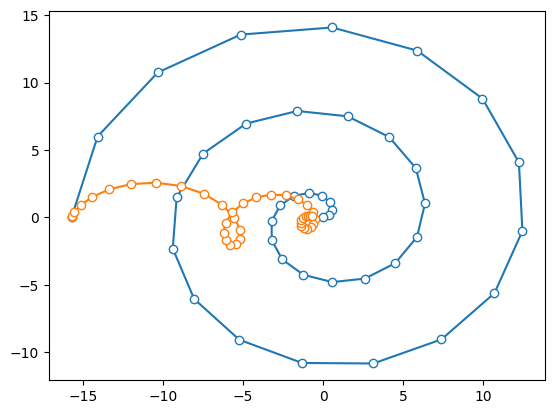

In [8]:
T = 1
q = 1
r = 100
Fi_RW_np = Fi_RW.evalf(subs={T_RW:T, q_RW:q})
Fi_RW_np = np.array(Fi_RW_np.tolist(), dtype=float)
Q_RW_np = Q_RW.evalf(subs={T_RW:T, q_RW: q})
Q_RW_np = np.array(Q_RW_np.tolist(), dtype=float)
H_np = np.array(H_RW.tolist(), dtype=float) 
# Define also the observation covariance 
R = r * np.array([[1,0], [0,1]])  
sx,sy = test_kalman(x,y,Fi_RW_np, H_np, Q_RW_np, R) 

plt.plot(x,y, marker='o', markerfacecolor="white")
plt.plot(sx,sy, marker='o', markerfacecolor="white")

### NCV

C:\Users\marko\AppData\Local\Temp\ipykernel_8860\914359342.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sx[j] = state[0]
C:\Users\marko\AppData\Local\Temp\ipykernel_8860\914359342.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sy[j] = state[1]


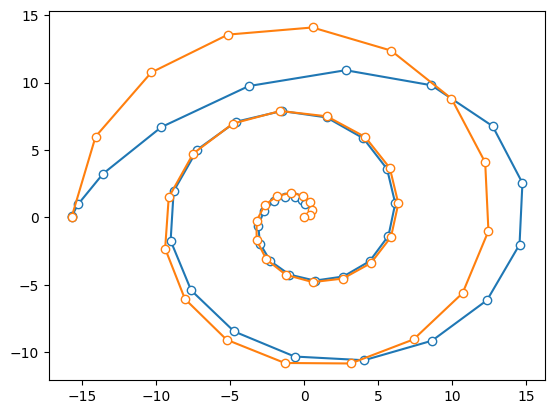

In [166]:
# Nearly constant velocity, input values into derived matrices
T = 1
q = 1
r = 100
Fi_NCV_np = Fi_NCV.evalf(subs={T_NCV:T, q_NCV:q})
Fi_NCV_np = np.array(Fi_NCV_np.tolist(), dtype=float)
Q_NCV_np = Q_NCV.evalf(subs={T_NCV:T, q_NCV: q})
Q_NCV_np = np.array(Q_NCV_np.tolist(), dtype=float)
H_np = np.array(H_NCV.tolist(), dtype=float)
# Define also the observation covariance 
R = r * np.array([[1,0], [0,1]])  
sx,sy = test_kalman(x,y,Fi_NCV_np, H_np, Q_NCV_np, R)  
 
plt.plot(sx,sy, marker='o', markerfacecolor="white")
plt.plot(x,y, marker='o', markerfacecolor="white")


### NCA

C:\Users\marko\AppData\Local\Temp\ipykernel_8860\914359342.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sx[j] = state[0]
C:\Users\marko\AppData\Local\Temp\ipykernel_8860\914359342.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sy[j] = state[1]


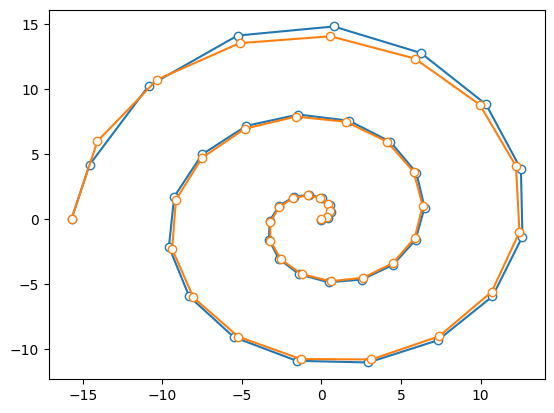

In [181]:
# Nearly constant velocity, input values into derived matrices
T = 1
q = 1
r = 1
Fi_NCA_np = Fi_NCA.evalf(subs={T_NCA:T, q_NCA:q})
Fi_NCA_np = np.array(Fi_NCA_np.tolist(), dtype=float)
Q_NCA_np = Q_NCA.evalf(subs={T_NCA:T, q_NCA: q})
Q_NCA_np = np.array(Q_NCA_np.tolist(), dtype=float)
H_np = np.array(H_NCA.tolist(), dtype=float)
# Define also the observation covariance 
R = r * np.array([[1,0], [0,1]])  
sx,sy = test_kalman(x,y,Fi_NCA_np, H_np, Q_NCA_np, R)  
 
plt.plot(sx,sy, marker='o', markerfacecolor="white")
plt.plot(x,y, marker='o', markerfacecolor="white")